In [ ]:
## Reference
# https://www.coursera.org/learn/introduction-computer-vision-watson-opencv

In [28]:
# PyTorch Library
import torch
# PyTorch Neural Network
import torch.nn as nn
# Allows us to transform data
import torchvision.transforms as transforms
# Allows us to download the dataset
import torchvision.datasets as dsets
# Used to graph data and loss curves
import matplotlib.pylab as plt
# Allows us to use arrays to manipulate and store data
import numpy as np

In [43]:
from common_params import parent_directory_images, parent_directory_url_csvs
import importlib
import sys,os
import pandas as pd
from timethis import timethis



In [3]:

module_path='../02_preprocess_data/preprocess_data_fns.py'
spec = importlib.util.spec_from_file_location("preprocess_data_fns", module_path)
preprocess_data_fns = importlib.util.module_from_spec(spec)
sys.modules["preprocess_data_fns"] = preprocess_data_fns
spec.loader.exec_module(preprocess_data_fns)
preprocess_data_fns.process_image_files

<function preprocess_data_fns.process_image_files(input_files: list, image_size: int = 256) -> list>

In [10]:
IMAGE_SIZE = 128
label_dict = {v:k for k,v in preprocess_data_fns.body_style_dict.items()}
label_dict

{0: 'sedan', 1: 'sportscar', 2: 'suv', 3: 'truck', 4: 'van', 5: 'wagon'}

### Ingest image data from disk

In [11]:
output_filename_train_val_holdout = f'{parent_directory_url_csvs}df_train_val_hold.csv'
df=pd.read_csv(output_filename_train_val_holdout).sample(frac=1)
print(df.shape)
df.partition.value_counts(dropna=False,normalize=True)

(8775, 9)


partition
train    0.715442
hold     0.154758
val      0.129801
Name: proportion, dtype: float64

0 2025-02-25 15:16:34.873324
torch.Size([128, 128])
292b7c2cbc024519aa81a5f0a84e10fe.jpg; true label truck


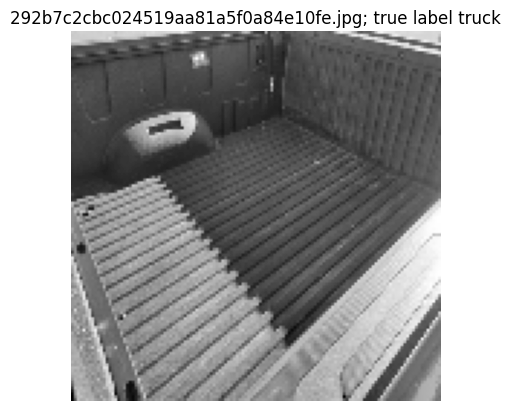

In [12]:
data_sample = df.head()[['filepath_to_use','body_style_index']].values
processed_images_sample = preprocess_data_fns.process_image_files(data_sample[:10], image_size=IMAGE_SIZE)

i=2
filename = os.path.basename(data_sample[i][0])
image_array = processed_images_sample[i][0].squeeze()
print(image_array.shape)
label = label_dict.get( processed_images_sample[i][1])
plt.imshow(image_array, cmap='gray')
plt.axis("off")
message=f"{filename}; true label {label}"
print(message)
plt.title(message)
plt.show()

In [13]:
train_dataset = preprocess_data_fns.process_image_files(
    df.loc[df['partition']=='train', ['filepath_to_use','body_style_index']].values,
    image_size=IMAGE_SIZE,
)

validation_dataset = preprocess_data_fns.process_image_files(
    df.loc[df['partition']=='val', ['filepath_to_use','body_style_index']].values,
    image_size=IMAGE_SIZE,
)

holdout_dataset = preprocess_data_fns.process_image_files(
    df.loc[df['partition']=='hold', ['filepath_to_use','body_style_index']].values,
    image_size=IMAGE_SIZE,
)

print(len(train_dataset),len(validation_dataset),len(holdout_dataset))

0 2025-02-25 15:16:51.636836
1000 2025-02-25 15:16:53.879018
2000 2025-02-25 15:16:55.887007
3000 2025-02-25 15:16:57.751620
4000 2025-02-25 15:16:59.619415
5000 2025-02-25 15:17:01.434943
6000 2025-02-25 15:17:03.341594
0 2025-02-25 15:17:03.820489
1000 2025-02-25 15:17:05.772840
0 2025-02-25 15:17:06.020733
1000 2025-02-25 15:17:07.934969
6278 1139 1358


Define the function <code>plot_channels</code> to plot out the kernel parameters of  each channel 


In [14]:
# Define the function for plotting the channels

def plot_channels(W):
    n_out = W.shape[0]
    n_in = W.shape[1]
    w_min = W.min().item()
    w_max = W.max().item()
    fig, axes = plt.subplots(n_out, n_in)
    fig.subplots_adjust(hspace=0.1)
    out_index = 0
    in_index = 0
    
    #plot outputs as rows inputs as columns 
    for ax in axes.flat:
        if in_index > n_in-1:
            out_index = out_index + 1
            in_index = 0
        ax.imshow(W[out_index, in_index, :, :], vmin=w_min, vmax=w_max, cmap='seismic')
        ax.set_yticklabels([])
        ax.set_xticklabels([])
        in_index = in_index + 1

    plt.show()


plot_channels

<function __main__.plot_channels(W)>

Define the function <code>plot_parameters</code> to plot out the kernel parameters of each channel with Multiple outputs. 


In [15]:
# Define the function for plotting the parameters

def plot_parameters(W, number_rows=1, name="", i=0):
    W = W.data[:, i, :, :]
    n_filters = W.shape[0]
    w_min = W.min().item()
    w_max = W.max().item()
    fig, axes = plt.subplots(number_rows, n_filters // number_rows)
    fig.subplots_adjust(hspace=0.4)

    for i, ax in enumerate(axes.flat):
        if i < n_filters:
            # Set the label for the sub-plot.
            ax.set_xlabel("kernel:{0}".format(i + 1))

            # Plot the image.
            ax.imshow(W[i, :], vmin=w_min, vmax=w_max, cmap='seismic')
            ax.set_xticks([])
            ax.set_yticks([])
    plt.suptitle(name, fontsize=10)    
    plt.show()

plot_parameters

<function __main__.plot_parameters(W, number_rows=1, name='', i=0)>

Define the function <code>plot_activation</code> to plot out the activations of the Convolutional layers  


In [16]:
# Define the function for plotting the activations

def plot_activations(A, number_rows=1, name="", i=0):
    A = A[0, :, :, :].detach().numpy()
    n_activations = A.shape[0]
    A_min = A.min().item()
    A_max = A.max().item()
    fig, axes = plt.subplots(number_rows, n_activations // number_rows)
    fig.subplots_adjust(hspace = 0.9)    

    for i, ax in enumerate(axes.flat):
        if i < n_activations:
            # Set the label for the sub-plot.
            ax.set_xlabel("activation:{0}".format(i + 1))

            # Plot the image.
            ax.imshow(A[i, :], vmin=A_min, vmax=A_max, cmap='seismic')
            ax.set_xticks([])
            ax.set_yticks([])
    plt.show()

plot_activations

<function __main__.plot_activations(A, number_rows=1, name='', i=0)>

Define the function <code>show_data</code> to plot out data samples as images.


In [17]:
def show_data(data_sample):
    # plt.imshow(data_sample[0].numpy().reshape(IMAGE_SIZE, IMAGE_SIZE), cmap='gray')
    # plt.title('y = '+ str(data_sample[1]))
    image_array = data_sample[0].squeeze()
    label = label_dict.get(data_sample[1])
    plt.imshow(image_array, cmap='gray')
    plt.axis("off")
    message=f"true label {label}"
    # print(message)
    plt.title(message)
    plt.show()

show_data

<function __main__.show_data(data_sample)>

<!--Empty Space for separating topics-->


Plot the fourth sample 


In [18]:
train_dataset[0]
print(train_dataset[0][0].shape)
print(type(train_dataset[0][0]))
# train_dataset[3][1]

torch.Size([1, 128, 128])
<class 'torch.Tensor'>


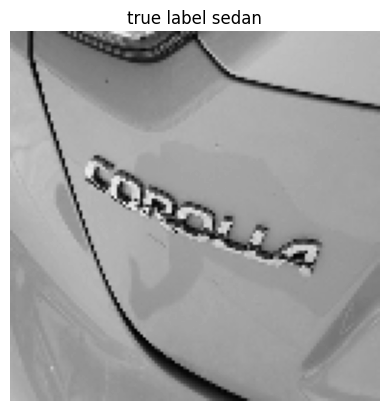

In [19]:
# The image for the fourth data element
show_data(train_dataset[3])

<!--Empty Space for separating topics-->


<h2 id="CNN">Build a Convolutional Neural Network Class</h2>


Build a Convolutional Network class with two Convolutional layers and one fully connected layer. Pre-determine the size of the final output matrix. The parameters in the constructor are the number of output channels for the first and second layers.

Channel Width can be calculated using the following formula

![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-CV0101EN-Coursera/labs/Module4/Channel_Width.png)

Channel width must be calculated after each CNN layer and Max Pool layer.

Default Values CNN Layer:

Stride: 1
Padding: 0
Dilation: 1

Default Values Max Pool Layer:

Stride: Kernel Size
Padding: 0
Dilation: 1


In [20]:
class CNN(nn.Module):

    # Contructor
    def __init__(self, out_1=16, out_2=32, image_size=IMAGE_SIZE):
        super(CNN, self).__init__()
        # The reason we start with 1 channel is because we have a single black and white image
        # Channel Width after this layer is 16
        self.cnn1 = nn.Conv2d(in_channels=1, out_channels=out_1, kernel_size=5, padding=2)
        # Channel Wifth after this layer is 8
        self.maxpool1=nn.MaxPool2d(kernel_size=2)

        # Channel Width after this layer is 8
        self.cnn2 = nn.Conv2d(in_channels=out_1, out_channels=out_2, kernel_size=5, stride=1, padding=2)
        # Channel Width after this layer is 4
        self.maxpool2=nn.MaxPool2d(kernel_size=2)
        # In total we have out_2 (32) channels which are each 4 * 4 in size based on the width calculation above. Channels are squares.
        # The output is a value for each class
        image_size_reduced = int(image_size/4)
        self.fc1 = nn.Linear(out_2 * image_size_reduced * image_size_reduced, 10)

    # Prediction
    def forward(self, x):
        # Puts the X value through each cnn, relu, and pooling layer and it is flattened for input into the fully connected layer
        x = self.cnn1(x)
        x = torch.relu(x)
        x = self.maxpool1(x)
        x = self.cnn2(x)
        x = torch.relu(x)
        x = self.maxpool2(x)
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        return x

    # Outputs result of each stage of the CNN, relu, and pooling layers
    def activations(self, x):
        # Outputs activation this is not necessary
        z1 = self.cnn1(x)
        a1 = torch.relu(z1)
        out = self.maxpool1(a1)

        z2 = self.cnn2(out)
        a2 = torch.relu(z2)
        out1 = self.maxpool2(a2)
        out = out.view(out.size(0),-1)
        return z1, a1, z2, a2, out1,out

<h2 id="Train">Define the Convolutional Neural Network Classifier, Criterion function, Optimizer, and Train the Model</h2> 


There are 16 output channels for the first layer, and 32 output channels for the second layer 


In [21]:
IMAGE_SIZE # too big loll

128

In [45]:
# Create the model object using CNN class

# model = CNN(out_1=IMAGE_SIZE, out_2=int(IMAGE_SIZE*2))
# model = CNN(out_1=16, out_2=32)
model = CNN(image_size=IMAGE_SIZE)

Plot the model parameters for the kernels before training the kernels. The kernels are initialized randomly.


Define the loss function, the optimizer, and the dataset loader 


In [46]:
# We create a criterion which will measure loss
criterion = nn.CrossEntropyLoss()
learning_rate = 0.1
# Create an optimizer that updates model parameters using the learning rate and gradient
optimizer = torch.optim.SGD(model.parameters(), lr = learning_rate)
# Create a Data Loader for the training data with a batch size of 100 
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=500)
# Create a Data Loader for the validation data with a batch size of 5000 
validation_loader = torch.utils.data.DataLoader(dataset=validation_dataset, batch_size=100)

Train the model and determine validation accuracy technically test accuracy **(This may take a long time)**


In [47]:
# Train the model

# Number of times we want to train on the taining dataset
n_epochs=5
# List to keep track of cost and accuracy
cost_list=[]
accuracy_list=[]
# Size of the validation dataset
N_test=len(validation_dataset)

# Model Training Function
def train_model(n_epochs):
    idx=0
    # Loops for each epoch
    for epoch in range(n_epochs):
        print("Epoch {}/{}".format(epoch+1, n_epochs))
        with timethis(f"epoch {epoch+1}"):
            # Keeps track of cost for each epoch
            COST=0
            # For each batch in train loader
            for x, y in train_loader:
                print(idx)
                idx+=1
                # Resets the calculated gradient value, this must be done each time as it accumulates if we do not reset
                optimizer.zero_grad()
                # Makes a prediction based on X value
                z = model(x)
                # Measures the loss between prediction and acutal Y value
                loss = criterion(z, y)
                # Calculates the gradient value with respect to each weight and bias
                loss.backward()
                # Updates the weight and bias according to calculated gradient value
                optimizer.step()
                # Cumulates loss
                COST+=loss.data

            # Saves cost of training data of epoch
            cost_list.append(COST)
            # Keeps track of correct predictions
            correct=0
            # Perform a prediction on the validation  data
            for x_test, y_test in validation_loader:
                # Makes a prediction
                z = model(x_test)
                # The class with the max value is the one we are predicting
                _, yhat = torch.max(z.data, 1)
                # Checks if the prediction matches the actual value
                correct += (yhat == y_test).sum().item()

            # Calcualtes accuracy and saves it
            accuracy = correct / N_test
            print(f'epoch {epoch+1}, cost = {COST}, accuracy = {accuracy}')
            accuracy_list.append(accuracy)

train_model(n_epochs)

Epoch 1/5
0
1
2
3
4
5
6
7
8
9
10
11
12
epoch 1, cost = 389067584.0, accuracy = 0.43810359964881473
epoch 1: 46.944 seconds
Epoch 2/5
13
14
15
16
17
18
19
20
21
22
23
24
25
epoch 2, cost = 26.851642608642578, accuracy = 0.43810359964881473
epoch 2: 47.573 seconds
Epoch 3/5
26
27
28
29
30
31
32
33
34
35
36
37
38
epoch 3, cost = 24.56895637512207, accuracy = 0.43810359964881473
epoch 3: 48.077 seconds
Epoch 4/5
39
40
41
42
43
44
45
46
47
48
49
50
51
epoch 4, cost = 22.990022659301758, accuracy = 0.43810359964881473
epoch 4: 46.014 seconds
Epoch 5/5
52
53
54
55
56
57
58
59
60
61
62
63
64
epoch 5, cost = 21.917022705078125, accuracy = 0.43810359964881473
epoch 5: 46.060 seconds


<!--Empty Space for separating topics-->


<h2 id="Result">Analyze Results</h2> 


Plot the loss and accuracy on the validation data:


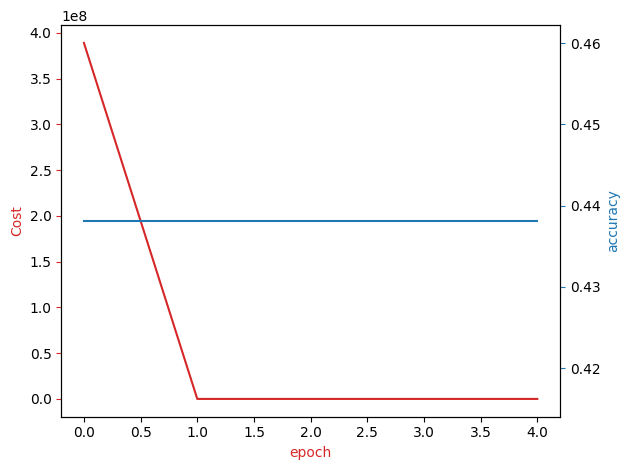

In [48]:
# Plot the Loss and Accuracy vs Epoch graph

fig, ax1 = plt.subplots()
color = 'tab:red'
ax1.plot(cost_list, color=color)
ax1.set_xlabel('epoch', color=color)
ax1.set_ylabel('Cost', color=color)
ax1.tick_params(axis='y', color=color)
    
ax2 = ax1.twinx()  
color = 'tab:blue'
ax2.set_ylabel('accuracy', color=color) 
ax2.set_xlabel('epoch', color=color)
ax2.plot( accuracy_list, color=color)
ax2.tick_params(axis='y', color=color)
fig.tight_layout()

In [27]:
accuracy_list

[0.43810359964881473]

View the results of the parameters for the Convolutional layers 


Consider the following sample 


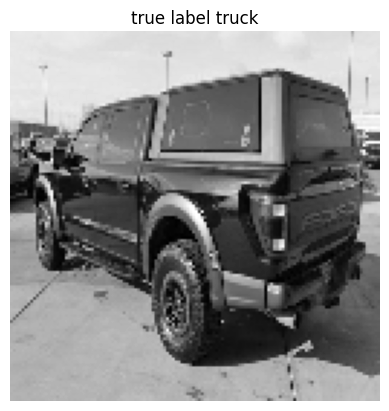

In [29]:
# Show the second image

show_data(train_dataset[1])

Determine the activations 


In [30]:
# Use the CNN activations class to see the steps

out = model.activations(train_dataset[1][0].view(1, 1, IMAGE_SIZE, IMAGE_SIZE))

Plot out the first set of activations 


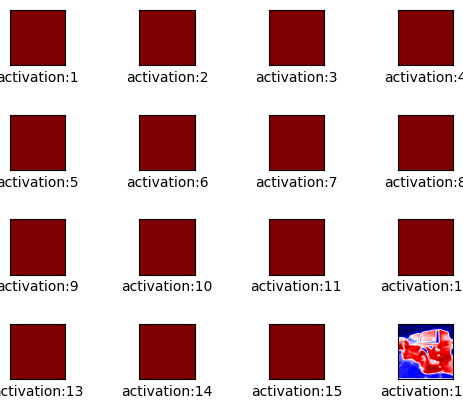

In [31]:
# Plot the outputs after the first CNN

plot_activations(out[0], number_rows=4, name="Output after the 1st CNN")

The image below is the result after applying the relu activation function 


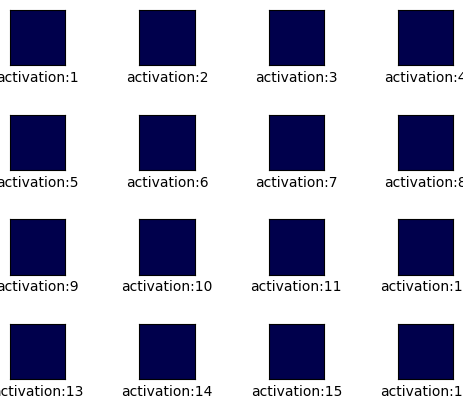

In [32]:
# Plot the outputs after the first Relu

plot_activations(out[1], number_rows=4, name="Output after the 1st Relu")

The image below is the result of the activation map after the second output layer.


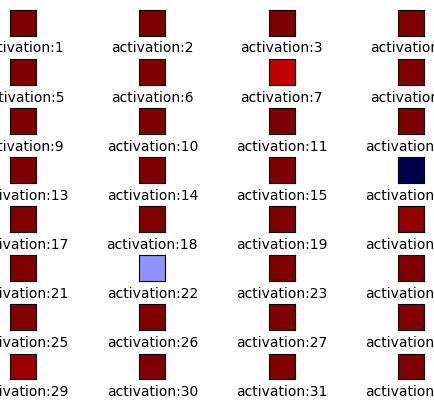

In [33]:
# Plot the outputs after the second CNN

plot_activations(out[2], number_rows=32 // 4, name="Output after the 2nd CNN")

The image below is the result of the activation map after applying the second relu  


In [ ]:
# Plot the outputs after the second Relu

plot_activations(out[3], number_rows=4, name="Output after the 2nd Relu")

We can  see the result for the third sample 


In [ ]:
# Show the third image

show_data(train_dataset[2])

In [ ]:
# Use the CNN activations class to see the steps

out = model.activations(train_dataset[2][0].view(1, 1, IMAGE_SIZE, IMAGE_SIZE))

In [ ]:
# Plot the outputs after the first CNN

plot_activations(out[0], number_rows=4, name="Output after the 1st CNN")

In [ ]:
# Plot the outputs after the first Relu

plot_activations(out[1], number_rows=4, name="Output after the 1st Relu")

In [ ]:
# Plot the outputs after the second CNN

plot_activations(out[2], number_rows=32 // 4, name="Output after the 2nd CNN")

In [ ]:
# Plot the outputs after the second Relu

plot_activations(out[3], number_rows=4, name="Output after the 2nd Relu")

Plot the first five misclassified samples:



true label = sedan, predict label = sedan


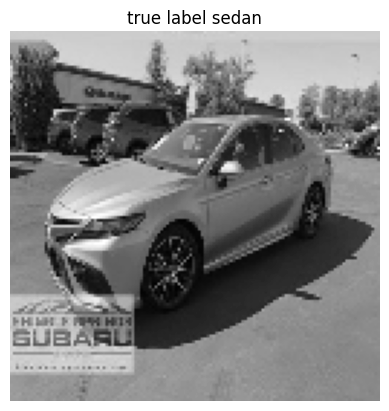


true label = sedan, predict label = sedan


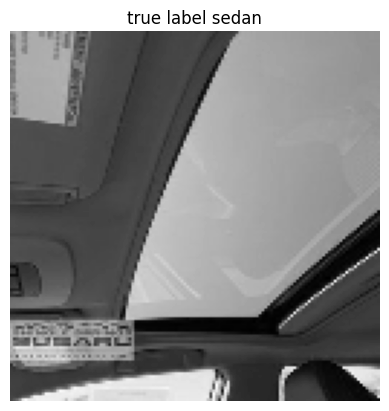


true label = sedan, predict label = sedan


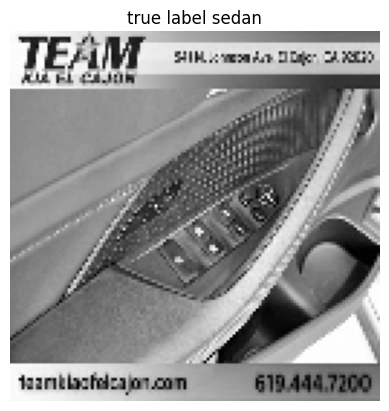


true label = wagon, predict label = sedan


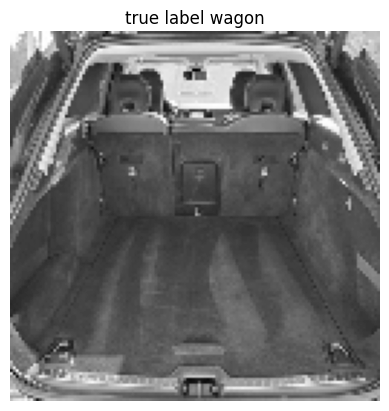


true label = truck, predict label = sedan


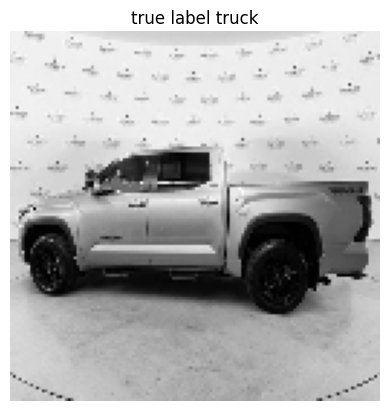

In [41]:
# Plot the misclassified samples

count = 0
for x, y in torch.utils.data.DataLoader(dataset=validation_dataset, batch_size=1):
    z = model(x)
    _, yhat = torch.max(z, 1)
    yhat = int(yhat)
    y=int(y)
    true_label = label_dict[y]
    pred_label = label_dict[yhat]
    # if yhat != y:
    print(f'\ntrue label = {true_label}, predict label = {pred_label}')
    show_data((x, y))
    plt.show()
    count += 1
    if count >= 5:
        break

In [39]:
int(yhat), int(y[0])

(0, 3)


<a href="https://dataplatform.cloud.ibm.com/registration/stepone?utm_source=skills_network&utm_content=in_lab_content_link&utm_id=Lab-IBMDeveloperSkillsNetwork-CV0101EN-Coursera&context=cpdaas&apps=data_science_experience%2Cwatson_machine_learning"><img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DL0110EN-SkillsNetwork/Template/module%201/images/Watson_Studio.png"></a>


<!--Empty Space for separating topics-->


<h2>About the Authors:</h2> 

<a href="https://www.linkedin.com/in/joseph-s-50398b136/">Joseph Santarcangelo</a> has a PhD in Electrical Engineering, his research focused on using machine learning, signal processing, and computer vision to determine how videos impact human cognition. Joseph has been working for IBM since he completed his PhD.


Other contributors: <a href="https://www.linkedin.com/in/michelleccarey/">Michelle Carey</a>, <a href="www.linkedin.com/in/jiahui-mavis-zhou-a4537814a">Mavis Zhou</a>


Thanks to Magnus <a href="http://www.hvass-labs.org/">Erik Hvass Pedersen</a> whose tutorials helped me understand Convolutional Neural Networks



## Change Log

|  Date (YYYY-MM-DD) |  Version | Changed By  |  Change Description |
|---|---|---|---|
| 2020-09-23  | 2.0  | Srishti  |  Migrated Lab to Markdown and added to course repo in GitLab |



<hr>

## <h3 align="center"> © IBM Corporation 2020. All rights reserved. <h3/>
